This notebook explains and tests our post-hoc overtransfection estimation method.

How can we know to what extent an emperical dataset might be overtransfected? i.e. how many barcode collisions there are per cell?

Suppose we draw $m$ total MPRA barcodes per cell, uniformly from $M$ different MPRA barcodes. The expected number of unique is

$$E[Unique]=M\left[1-\left( \frac{M-1}{M} \right)^m \right]$$

[link](https://stats.stackexchange.com/questions/296005/the-expected-number-of-unique-elements-drawn-with-replacement)

We can measure the number of unique MPRA barcodes in each cell. We want to calculate $m$, actual number of transfected barcodes. Note that we are just assuming that observed unique is the expected value of unique, which is a big approximation.

$$\frac{E[Unique]}{M}=\left[1-\left( \frac{M-1}{M} \right)^m \right]$$

$$\left( \frac{M-1}{M} \right)^m=1-\frac{E[Unique]}{M}$$

$$  m=ln\left(1-\frac{E[Unique]}{M}\right)/ln\left(\frac{M-1}{M}\right)$$

That formula is used in the `Bounds` object, .

Let's test it with a bit of simulation. Let's begin by getting some ballpark figures :

In [1]:
import scMPRAforge as scm
import numpy as np
import pandas as pd
from itertools import product

2025-10-08 15:25:05.105898: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 15:25:05.920232: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

Ballpark total cells:

In [2]:
scm.SHENDURE_BOUNDS.cells_per_cell_type.sum()

43389

Ballpark total MPRA bc:

In [3]:
scm.SHENDURE_BOUNDS.total_uniq_mpra_bc

28300

Ballpark MOI:

In [4]:
scm.SHENDURE_BOUNDS.transfection_model.mu_nb

18.01055567079214

Define some functions:

In [5]:
def simple_transfection(bound,total_cells,library_size):
    #Similar logic to _simulate_single_replicate_transfection()

    #create barcodes
    cbc=scm.generate_barcodes(length=10, count=total_cells)
    mpra_bc=scm.generate_barcodes(length=10, count=library_size)
    #create ret df
    cells_df=pd.DataFrame({'cell_bc':cbc})
    #decide how many transfected into each cell
    cells_df["num_transfected"]=bound.transfection_model.draw_nb(len(cells_df))
    #repeat, so there is one row per tfection event
    cells_df=cells_df.loc[cells_df.index.repeat(cells_df["num_transfected"])].reset_index(drop=True)
    #drop num transfected, since it is no longer required
    cells_df=cells_df.drop(columns=["num_transfected"])
    #sample mprabc
    cells_df["mpra_bc"]=np.random.choice(mpra_bc, size=len(cells_df), replace=True)
    return cells_df

def emperical_collision_number(cell_df):
    cell_df=cell_df.groupby(["cell_bc"])["mpra_bc"].agg(total_plasmid="count",unique_plasmid="nunique")
    return cell_df["total_plasmid"].sum()-cell_df["unique_plasmid"].sum()

def estimate_collisions(cell_df):
    #drop duplicates, simulating collision process
    cell_df=cell_df.drop_duplicates()
    #estimate total mprabc
    estimated_total_uniq_mprabc=len(cell_df["mpra_bc"].unique())
    #get num unique mprabc transfected into each cell
    tfection=cell_df.groupby(["cell_bc"])["mpra_bc"].nunique().reset_index()
    tfection=tfection.rename({"mpra_bc":"unique_mpra_bc"},axis=1)
    #compute how many we think there actually were
    observed=tfection["unique_mpra_bc"]
    tfection["tot_plasmid"]=np.log(1-observed/estimated_total_uniq_mprabc)/np.log((estimated_total_uniq_mprabc-1)/estimated_total_uniq_mprabc)
    return tfection['tot_plasmid'].sum()-tfection["unique_mpra_bc"].sum()


Example of use...

In [6]:
toy=simple_transfection(bound=scm.SHENDURE_BOUNDS,
    total_cells=43389,
    library_size=28300)

print(f"Ground-truth collisions {emperical_collision_number(toy)}")
print(f"Estimated collisions {estimate_collisions(toy)}")


Ground-truth collisions 388
Estimated collisions 386.02963009430096


Now let's create a set of sets of reasonable experimental parameters

In [7]:
total_cells = np.arange(1000, 10**6, 200000)
MOI = np.arange(5, 100, 5)
library_size = np.arange(10000, 100000, 20000)

params = pd.DataFrame(
    product(total_cells, MOI, library_size),
    columns=["total_cells", "MOI", "library_size"]
)
#params

Now let's simulate each of those in parallel.

In [8]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='64GB')
client=Client(cluster)

In [9]:
results=[]
for rownum, row in params.iterrows():
    synthetic_bounds=scm.SHENDURE_BOUNDS.copy()
    synthetic_bounds.set_effective_moi(row["MOI"])
    results.append(client.submit(simple_transfection, 
                                bound=synthetic_bounds,
                                total_cells=row["total_cells"],
                                library_size=row["library_size"]))

Apply the collision estimation & calculation

In [10]:
gt_collisions=[]
total_tfection_events=[]
estimated_collisions=[]
for i in results:
    gt_collisions.append(client.submit(emperical_collision_number, i))
    estimated_collisions.append(client.submit(estimate_collisions, i))
    total_tfection_events.append(client.submit(len,i))


Gather & add to the df

In [11]:
params["total_transfection_events"]=client.gather(total_tfection_events)
params["gt_collisions"]=client.gather(gt_collisions)
params["estimated_collisions"]=client.gather(estimated_collisions)
params

2025-10-08 15:54:27,717 - distributed.dashboard.components.shared - ERROR - 'NoneType' object has no attribute 'add_next_tick_callback'
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/utils.py", line 818, in wrapper
    return await func(*args, **kwargs)
  File "/home/mcn26/.conda/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/dashboard/components/shared.py", line 327, in cb
    self.doc().add_next_tick_callback(lambda: self.update(prof, metadata))
AttributeError: 'NoneType' object has no attribute 'add_next_tick_callback'
2025-10-08 15:54:27,729 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x1500c43036a0>>, <Task finished name='Task-749740' coro=<ProfileTimePlot.trigger_update.<locals>.cb() done, defined at /home/mcn26/.conda/envs/env_tensorzinb/lib/python3.10/site-packages

,total_cells,MOI,library_size,total_transfection_events,gt_collisions,estimated_collisions
0,1000,5,10000,4885,5,4.694282
1,1000,5,30000,5151,1,4.440386
2,1000,5,50000,5103,0,4.268167
3,1000,5,70000,5269,1,4.321714
4,1000,5,90000,4968,0,3.867883
...,...,...,...,...,...,...
470,801000,95,10000,76153698,565322,565001.473565
471,801000,95,30000,76182776,189234,189397.608790
472,801000,95,50000,76120908,113579,113423.295946
473,801000,95,70000,76111762,80976,81053.401995


Looks good. We want to determine the error in our estimation method. The parameter we care about is "percent of data points which are collisions, and so are doubled in size". So we compute what the real parameter value is & estimate & compute error between those...

In [12]:
params["estimated_collision_rate"]=params["estimated_collisions"]/params["total_transfection_events"]
params["gt_collision_rate"]=params["gt_collisions"]/params["total_transfection_events"]
params["percent_estimation_error"]=np.abs((params["estimated_collision_rate"]-params["gt_collision_rate"])/params["gt_collision_rate"]*100)

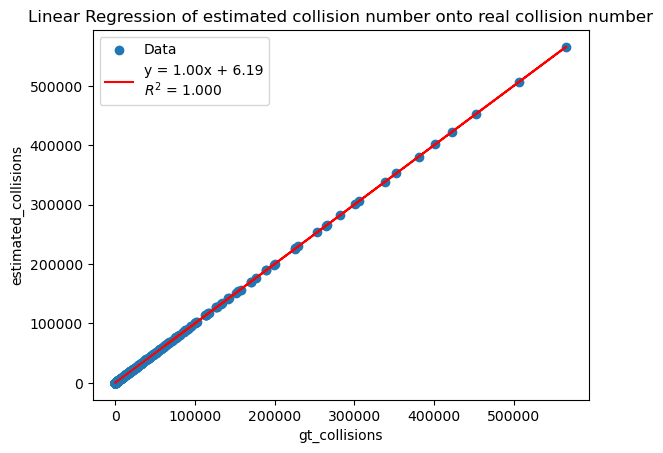

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Perform linear regression
x = params["gt_collisions"]
y = params["estimated_collisions"]
slope, intercept = np.polyfit(x, y, 1)
fit_line = slope * x + intercept

# Compute R²
r_value = np.corrcoef(x, y)[0, 1]
r2 = r_value ** 2

# Plot data and regression line
plt.scatter(x, y, label="Data")
plt.plot(x, fit_line, color="red", 
         label=f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r2:.3f}")
plt.xlabel("gt_collisions")
plt.ylabel("estimated_collisions")
plt.legend()
plt.title("Linear Regression of estimated collision number onto real collision number")
plt.show()

Quite a high correlation !

In [15]:
params.to_csv("20251008_parameters.tsv",sep="\t")